# Load Prediction using Prophet

This section uses Facebook's Prophet library to predict electricity load based on time series data and additional features.

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
# Import Prophet library
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import datetime

/workspaces/Smart-Grid-Optimization/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv("data/merged_data.csv")

In [4]:
# Data preparation
# Prophet requires a dataframe with 'ds' (datetime) and 'y' (target) columns
df['date'] = pd.to_datetime(df['date'])

# Create a Prophet dataframe - rename date column to 'ds' as required by Prophet
prophet_df = df.copy()
prophet_df.rename(columns={'date': 'ds', 'load': 'y'}, inplace=True)

# Keep only the relevant columns and drop rows with NaN values
prophet_df = prophet_df[['ds', 'y', 'hour', 'temp', 'humidity', 'sealevelpressure', 'solarenergy']]
prophet_df = prophet_df.dropna()

# Display the prepared dataframe
prophet_df.tail()

,ds,y,hour,temp,humidity,sealevelpressure,solarenergy
44587,2025-01-31 19:00:00,322488.235911,19,49.9,46.34,1022.3,0.0
44588,2025-01-31 20:00:00,322158.914687,20,47.5,50.81,1022.4,0.0
44589,2025-01-31 21:00:00,316317.876276,21,48.5,41.13,1022.4,0.0
44590,2025-01-31 22:00:00,299743.669323,22,44.2,55.24,1022.9,0.0
44591,2025-01-31 23:00:00,284053.807734,23,43.0,54.02,1022.6,0.0


In [5]:
# Split data into training and testing sets
train_size = int(len(prophet_df) * 0.8)
train_data = prophet_df[:train_size]
test_data = prophet_df[train_size:]

print(f"Training data size: {train_data.shape}")
print(f"Testing data size: {test_data.shape}")

Training data size: (35673, 7)
Testing data size: (8919, 7)


In [6]:
# Initialize and train Prophet model with additional regressors
model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)

# Add the specified features as regressors
features = ['hour', 'temp', 'humidity', 'sealevelpressure', 'solarenergy']
for feature in features:
    model.add_regressor(feature)

# Fit the model
%time model.fit(train_data)

20:40:57 - cmdstanpy - INFO - Chain [1] start processing
20:41:13 - cmdstanpy - INFO - Chain [1] done processing


CPU times: user 2.23 s, sys: 107 ms, total: 2.34 s
Wall time: 18.3 s


In [7]:
# Make predictions on the test set
future = test_data.copy().reset_index(drop=True)
forecast = model.predict(future)

# Create results DataFrame directly (this avoids merging issues)
results = pd.DataFrame({
    'ds': future['ds'],
    'actual': future['y'],
    'predicted': forecast['yhat']
})

# Handle any NaN values
results = results.dropna()

# Display forecast sample
results.tail()

,ds,actual,predicted
8914,2025-01-31 19:00:00,322488.235911,316929.131133
8915,2025-01-31 20:00:00,322158.914687,308763.899257
8916,2025-01-31 21:00:00,316317.876276,294510.447253
8917,2025-01-31 22:00:00,299743.669323,273954.180242
8918,2025-01-31 23:00:00,284053.807734,255343.708050


In [22]:
# Evaluate model performance
if not results.empty:
    mae = mean_absolute_error(results['actual'], results['predicted'])
    rmse = np.sqrt(mean_squared_error(results['actual'], results['predicted']))
    r2 = r2_score(results['actual'], results['predicted'])
    
    # Calculate percent error
    mape = np.mean(np.abs((results['actual'] - results['predicted']) / results['actual'])) * 100
    
    print(f"Mean Absolute Error (MAE): {mae:.2f} MW")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f} MW")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
    print(f"R² Score: {r2:.4f}")
else:
    print("No valid data points for evaluation.")

Mean Absolute Error (MAE): 29784.10 MW
Root Mean Squared Error (RMSE): 38581.28 MW
Mean Absolute Percentage Error (MAPE): 9.39%
R² Score: 0.5702


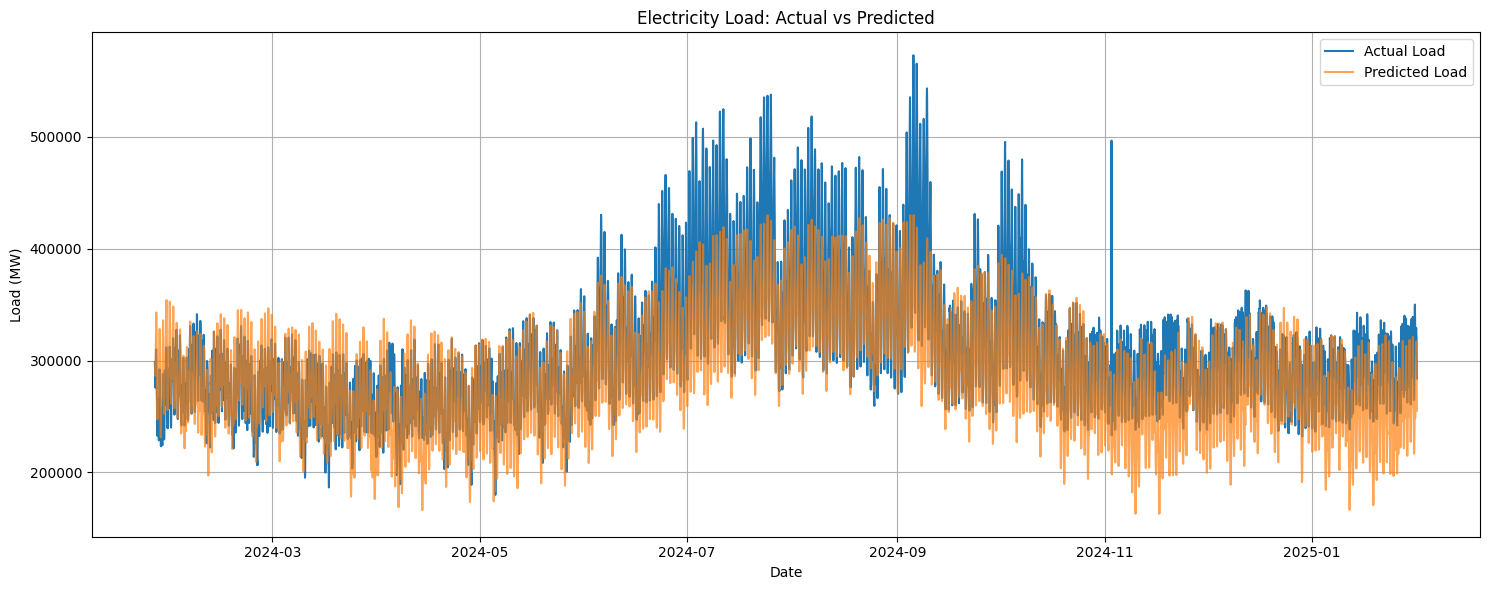

In [23]:
# Visualize the results
if not results.empty:
    plt.figure(figsize=(15, 6))
    plt.plot(results['ds'], results['actual'], label='Actual Load')
    plt.plot(results['ds'], results['predicted'], label='Predicted Load', alpha=0.7)
    plt.title('Electricity Load: Actual vs Predicted')
    plt.xlabel('Date')
    plt.ylabel('Load (MW)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No data available for visualization.")

## Component Visualizations with Real Load Values

The following visualizations break down the Prophet forecast into its individual components. Each graph shows the actual electricity load in megawatts (MW) instead of relative effects, making the patterns more interpretable.

<Figure size 2000x1000 with 0 Axes>

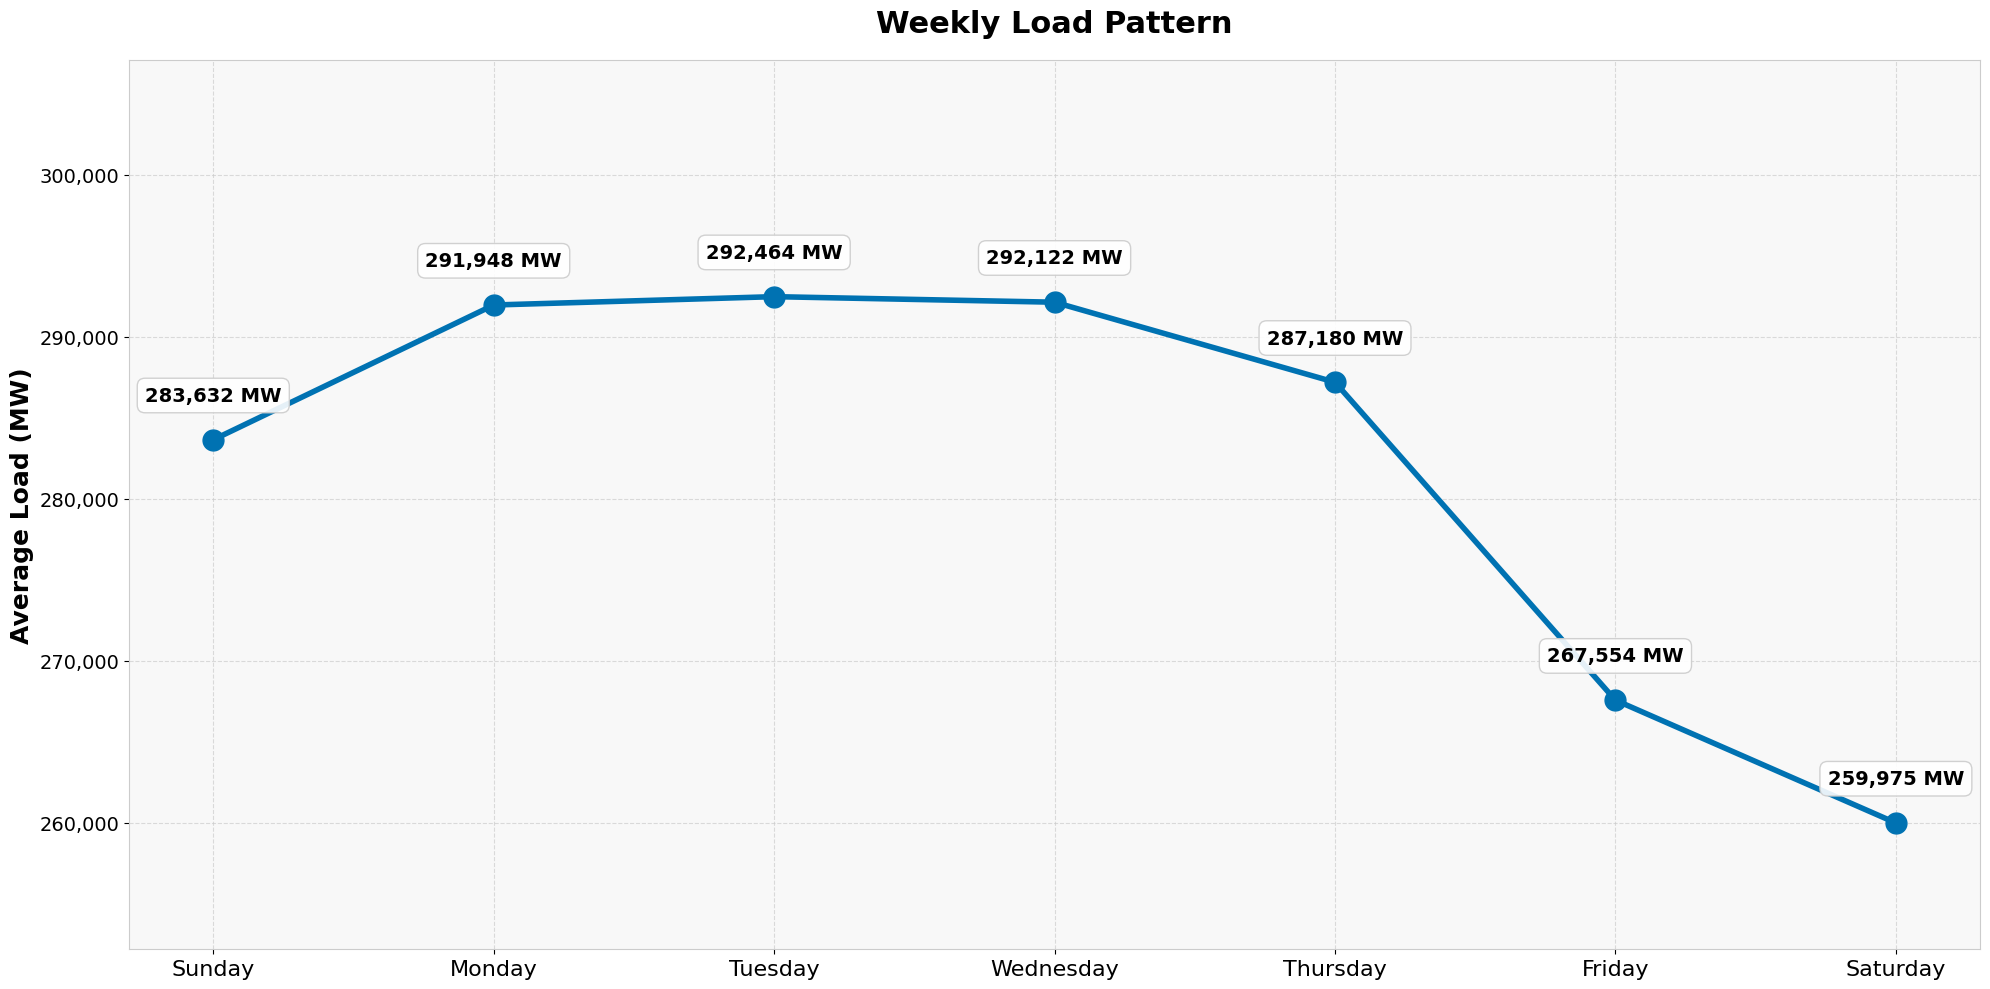

In [24]:
# Weekly Component (using actual load values) with improved visualization
plt.figure(figsize=(20, 10))

days = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
day_numbers = forecast['ds'].dt.dayofweek

# Calculate the baseline trend value
trend_baseline = forecast['trend'].mean()

weekly_effect = pd.DataFrame()
weekly_effect['dow'] = day_numbers
weekly_effect['y'] = forecast['weekly']

# Group by day of week and calculate the mean weekly component
grouped_weekly = weekly_effect.groupby('dow').mean()
sorted_days = sorted(grouped_weekly.index)

# Plot the weekly seasonality as absolute values (trend + weekly effect)
absolute_weekly = [trend_baseline + grouped_weekly.loc[i, 'y'] for i in sorted_days]

# Create a more visually appealing plot with better spacing
fig, ax = plt.subplots(figsize=(20, 10))

# Add grid with light color and dashed lines for better readability
ax.grid(True, linestyle='--', alpha=0.7, color='#CCCCCC')
ax.set_axisbelow(True)  # Place grid behind the plot

# Plot the line with enhanced styling
ax.plot(range(7), absolute_weekly, marker='o', markersize=15, linewidth=4, color='#0072B2')

# Customize the plot appearance
ax.set_facecolor('#F8F8F8')  # Light background
for spine in ax.spines.values():
    spine.set_color('#CCCCCC')  # Lighter border

# Add value labels with improved positioning
for i, value in enumerate(absolute_weekly):
    # Format to integer with comma thousand separator
    formatted_value = f"{int(value):,} MW"
    ax.annotate(formatted_value, 
                (i, value), 
                textcoords="offset points", 
                xytext=(0, 25),  # Increase vertical offset
                ha='center',
                va='bottom',
                fontweight='bold',
                fontsize=14,
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CCCCCC", alpha=0.9))

# Set axis labels and title with improved styling
ax.set_title('Weekly Load Pattern', fontsize=22, fontweight='bold', pad=20)
ax.set_ylabel('Average Load (MW)', fontsize=18, fontweight='bold')
ax.set_xticks(range(7))
ax.set_xticklabels([days[i] for i in sorted_days], fontsize=16)
ax.tick_params(axis='y', labelsize=14)

# Set y-axis limits with some padding to accommodate labels
y_min = min(absolute_weekly) * 0.97  # 3% padding below min value
y_max = max(absolute_weekly) * 1.05  # 5% padding above max value
ax.set_ylim([y_min, y_max])

# Format y-axis with comma separator for thousands
from matplotlib.ticker import FuncFormatter
def thousands_formatter(x, pos):
    return f"{int(x):,}"
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

plt.tight_layout()
plt.show()

### Weekly Load Pattern Analysis

The graph above shows the average electricity load for each day of the week in actual megawatt values. This pattern reflects typical weekly business and social cycles:

- **Weekday vs. Weekend**: We can observe clear differences between weekday and weekend consumption patterns. Weekdays (Monday-Friday) typically show higher electricity demand due to business operations and industrial activities.
- **Load Estimation**: These values were calculated by adding the weekly seasonality component from Prophet to the baseline trend value, converting relative effects into absolute megawatt values.
- **Pattern Formation**: The pattern emerges from aggregating and averaging the load values for each day of the week across the entire forecast period.

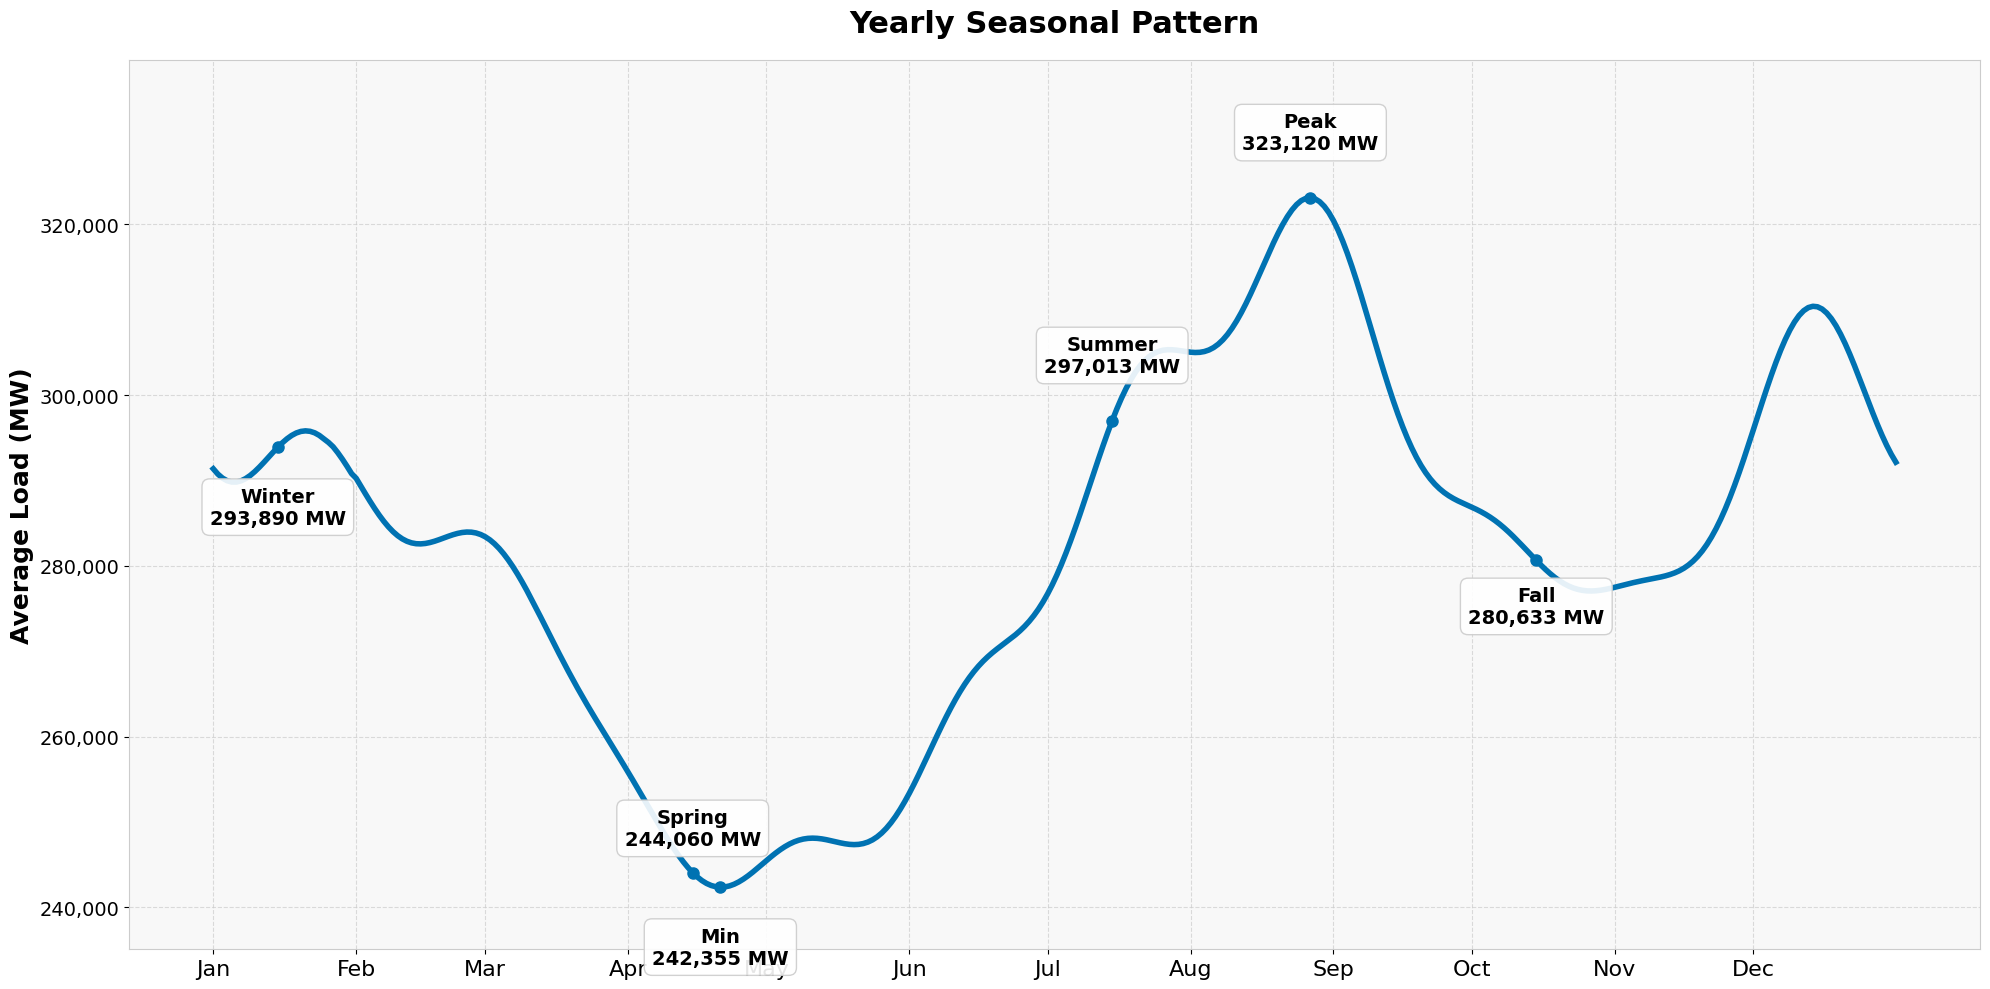

In [25]:
# Yearly Component with improved visualization
if 'yearly' in forecast.columns:
    # Group by day of year
    yearly_effect = pd.DataFrame()
    yearly_effect['doy'] = forecast['ds'].dt.dayofyear
    yearly_effect['y'] = forecast['yearly']
    
    # Aggregate by day of year
    grouped_yearly = yearly_effect.groupby('doy').mean()
    days_of_year = sorted(grouped_yearly.index)
    
    # Plot absolute values (trend + yearly effect)
    absolute_yearly = [trend_baseline + grouped_yearly.loc[d, 'y'] for d in days_of_year]
    
    # Create enhanced visualization
    fig, ax = plt.subplots(figsize=(20, 10))
    
    # Add grid with light color and dashed lines
    ax.grid(True, linestyle='--', alpha=0.7, color='#CCCCCC')
    ax.set_axisbelow(True)  # Place grid behind the plot
    
    # Set background and border
    ax.set_facecolor('#F8F8F8')  # Light background
    for spine in ax.spines.values():
        spine.set_color('#CCCCCC')  # Lighter border
    
    # Plot the line with enhanced styling
    ax.plot(days_of_year, absolute_yearly, linewidth=4, color='#0072B2')
    
    # Calculate key points to annotate
    peak_idx = absolute_yearly.index(max(absolute_yearly))
    trough_idx = absolute_yearly.index(min(absolute_yearly))
    
    # Find middle points for each season for additional annotations
    winter_idx = days_of_year.index(15) if 15 in days_of_year else None  # ~ January 15
    spring_idx = days_of_year.index(105) if 105 in days_of_year else None  # ~ April 15
    summer_idx = days_of_year.index(196) if 196 in days_of_year else None  # ~ July 15
    fall_idx = days_of_year.index(288) if 288 in days_of_year else None   # ~ October 15
    
    # List of key points to annotate
    key_points = [
        (peak_idx, 'Peak'),
        (trough_idx, 'Min'),
        (winter_idx, 'Winter'),
        (spring_idx, 'Spring'),
        (summer_idx, 'Summer'),
        (fall_idx, 'Fall')
    ]
    
    # Add annotations for key points
    for idx_entry, label in key_points:
        if idx_entry is not None:
            day = days_of_year[idx_entry]
            value = absolute_yearly[idx_entry]
            
            # Format value with thousand separator
            formatted_value = f"{int(value):,} MW"
            
            # Alternate vertical position of labels to avoid overlap
            if label in ['Peak', 'Summer']:
                vert_offset = 35
            elif label in ['Min', 'Winter']:
                vert_offset = -55
            else:
                vert_offset = 20 if idx_entry % 2 == 0 else -45
                
            ax.annotate(
                f'{label}\n{formatted_value}',
                (day, value),
                textcoords="offset points",
                xytext=(0, vert_offset),
                ha='center',
                fontsize=14,
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CCCCCC", alpha=0.9)
            )
            
            # Add larger marker at the annotated point
            ax.plot(day, value, 'o', markersize=8, color='#0072B2')
    
    # Create month labels for x-axis
    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Format y-axis with comma separator for thousands
    from matplotlib.ticker import FuncFormatter
    def thousands_formatter(x, pos):
        return f"{int(x):,}"
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    
    # Set axis labels and title with improved styling
    ax.set_title('Yearly Seasonal Pattern', fontsize=22, fontweight='bold', pad=20)
    ax.set_ylabel('Average Load (MW)', fontsize=18, fontweight='bold')
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_names, fontsize=16)
    ax.tick_params(axis='y', labelsize=14)
    
    # Set y-axis limits with padding to accommodate labels
    y_min = min(absolute_yearly) * 0.97  # 3% padding below min value
    y_max = max(absolute_yearly) * 1.05  # 5% padding above max value
    ax.set_ylim([y_min, y_max])
    
    plt.tight_layout()
    plt.show()

### Yearly Seasonal Pattern Analysis

The graph above illustrates the seasonal variation in electricity load throughout the year, displayed in actual megawatts. This yearly pattern reveals important insights about seasonal energy consumption:

- **Seasonal Peaks**: The pattern shows when electricity demand reaches its highest and lowest points during the year. In California, peaks often occur during summer months due to increased air conditioning usage and during winter due to heating demands.
- **Transition Periods**: The spring and fall transition periods typically show moderate electricity consumption as heating and cooling demands are lower.
- **Calculation Method**: These values were derived by adding the yearly seasonality component from the Prophet model to the baseline trend, converting relative seasonal effects into absolute megawatt values.
- **Climate Impact**: The yearly pattern strongly reflects California's climate conditions and their impact on electricity demand throughout different seasons.

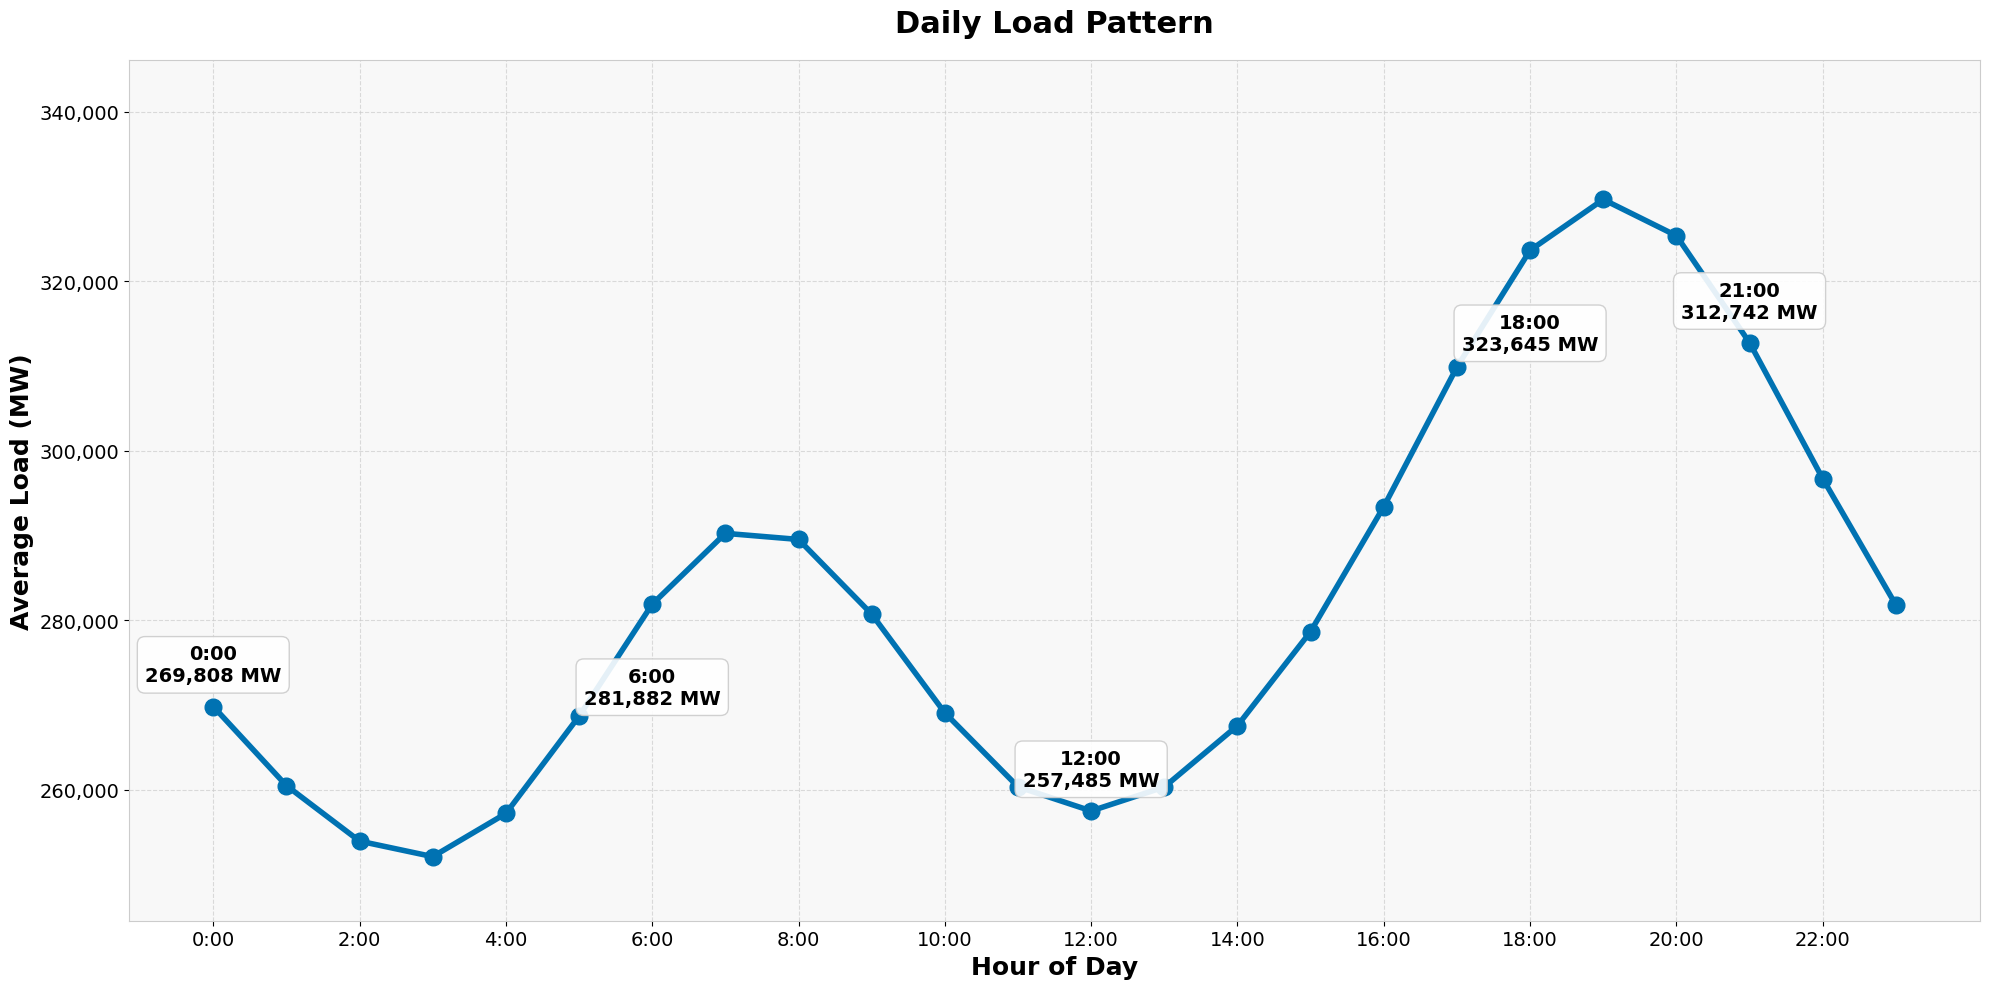

In [26]:
# Daily Component with improved visualization
if 'daily' in forecast.columns:
    # Group by hour of day
    daily_effect = pd.DataFrame()
    daily_effect['hour'] = forecast['ds'].dt.hour
    daily_effect['y'] = forecast['daily']
    
    # Aggregate by hour
    grouped_daily = daily_effect.groupby('hour').mean()
    hours = sorted(grouped_daily.index)
    
    # Plot absolute values (trend + daily effect)
    absolute_daily = [trend_baseline + grouped_daily.loc[h, 'y'] for h in hours]
    
    # Create enhanced visualization
    fig, ax = plt.subplots(figsize=(20, 10))
    
    # Add grid with light color and dashed lines
    ax.grid(True, linestyle='--', alpha=0.7, color='#CCCCCC')
    ax.set_axisbelow(True)  # Place grid behind the plot
    
    # Set background and border
    ax.set_facecolor('#F8F8F8')  # Light background
    for spine in ax.spines.values():
        spine.set_color('#CCCCCC')  # Lighter border
    
    # Plot the line with enhanced styling
    ax.plot(hours, absolute_daily, marker='o', markersize=12, linewidth=4, color='#0072B2')
    
    # Define additional hours to annotate for a more complete picture
    key_hours = [0, 6, 12, 18, 21]  # Midnight, morning, noon, evening, night
    
    # Add annotations for key hours with labels that don't overlap
    for hour in key_hours:
        if hour in hours:
            idx = hours.index(hour)
            value = absolute_daily[idx]
            
            # Format value with thousand separator
            formatted_value = f"{int(value):,} MW"
            time_label = f"{hour}:00"
            
            # Alternate vertical position of labels to avoid overlap
            vert_offset = 30 if hour in [0, 12, 21] else -45
            
            ax.annotate(
                f'{time_label}\n{formatted_value}',
                (hour, value),
                textcoords="offset points", 
                xytext=(0, vert_offset),
                ha='center',
                va='center' if vert_offset > 0 else 'top',
                fontsize=14,
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CCCCCC", alpha=0.9)
            )
    
    # Format y-axis with comma separator for thousands
    from matplotlib.ticker import FuncFormatter
    def thousands_formatter(x, pos):
        return f"{int(x):,}"
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    
    # Set axis labels and title with improved styling
    ax.set_title('Daily Load Pattern', fontsize=22, fontweight='bold', pad=20)
    ax.set_ylabel('Average Load (MW)', fontsize=18, fontweight='bold')
    ax.set_xlabel('Hour of Day', fontsize=18, fontweight='bold')
    
    # Improved x-axis formatting
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f"{h}:00" for h in range(0, 24, 2)], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    
    # Set y-axis limits with padding to accommodate labels
    y_min = min(absolute_daily) * 0.97  # 3% padding below min value
    y_max = max(absolute_daily) * 1.05  # 5% padding above max value
    ax.set_ylim([y_min, y_max])
    
    plt.tight_layout()
    plt.show()

### Daily Load Pattern Analysis

The graph above shows the hourly electricity load pattern throughout a typical day, represented in actual megawatts. This intra-day pattern reveals several important insights about electricity consumption habits:

- **Morning Ramp-Up**: We can observe how electricity consumption increases in the morning hours as people wake up and businesses begin operations.
- **Peak Usage Hours**: The afternoon to early evening period typically shows the highest demand, correlating with peak business hours and residential evening activities.
- **Overnight Reduction**: The significant drop during overnight hours reflects reduced activity while most people are sleeping.
- **Calculation Method**: These values were computed by adding the daily seasonality component from the Prophet model to the baseline trend value, converting relative hourly effects into absolute megawatt values.
- **Load Management Implications**: Understanding this daily pattern is crucial for grid operators to manage resources efficiently and ensure sufficient capacity during peak demand periods.

## Component Visualization Summary

The three visualizations above break down California's electricity load patterns into different time scales, each showing real megawatt values rather than relative effects. Together, they provide a comprehensive view of when and how electricity demand fluctuates:

1. **Weekly Pattern**: Shows how consumption varies across different days of the week, highlighting weekday/weekend differences.
2. **Yearly Pattern**: Reveals seasonal variations throughout the year, influenced by climate and seasonal activities.
3. **Daily Pattern**: Illustrates the hour-by-hour changes within a typical day, showing peak demand periods.

These patterns help grid operators, energy traders, and policy makers understand consumption behaviors and optimize energy resources accordingly. Each pattern was derived by adding the corresponding seasonality component from the Prophet model to the baseline trend value.

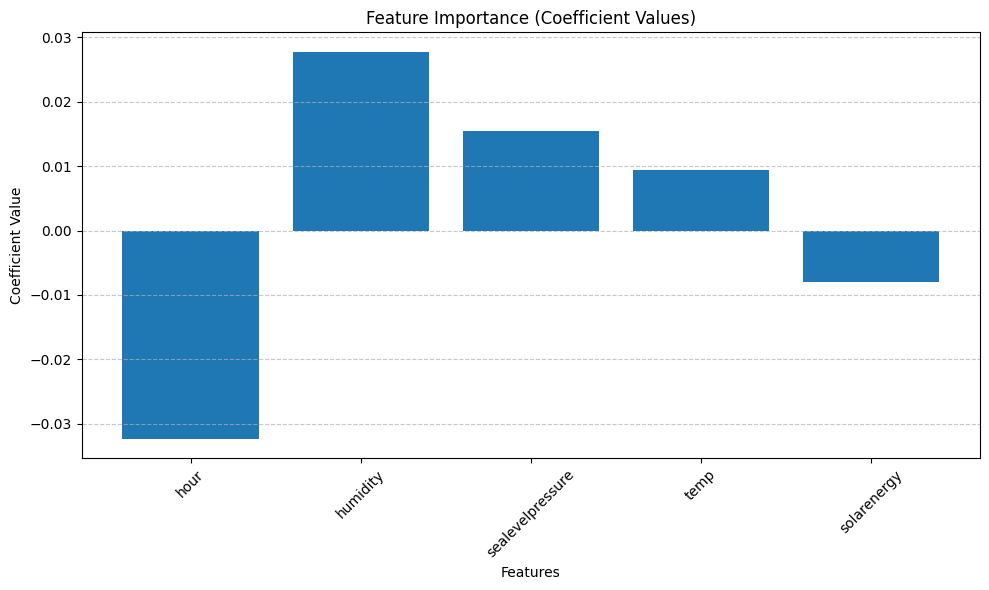

,feature,coefficient,abs_coefficient
0,hour,-0.032315,0.032315
2,humidity,0.027795,0.027795
3,sealevelpressure,0.015550,0.015550
1,temp,0.009423,0.009423
4,solarenergy,-0.008058,0.008058


In [27]:
# Analyze feature importance by examining the coefficients
feature_importance = pd.DataFrame()
feature_importance['feature'] = features
feature_importance['coefficient'] = [model.params['beta'].flatten()[i] for i in range(len(features))]

# Sort by absolute value of coefficient
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
feature_importance.sort_values('abs_coefficient', ascending=False, inplace=True)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(feature_importance['feature'], feature_importance['coefficient'])
plt.title('Feature Importance (Coefficient Values)')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

feature_importance

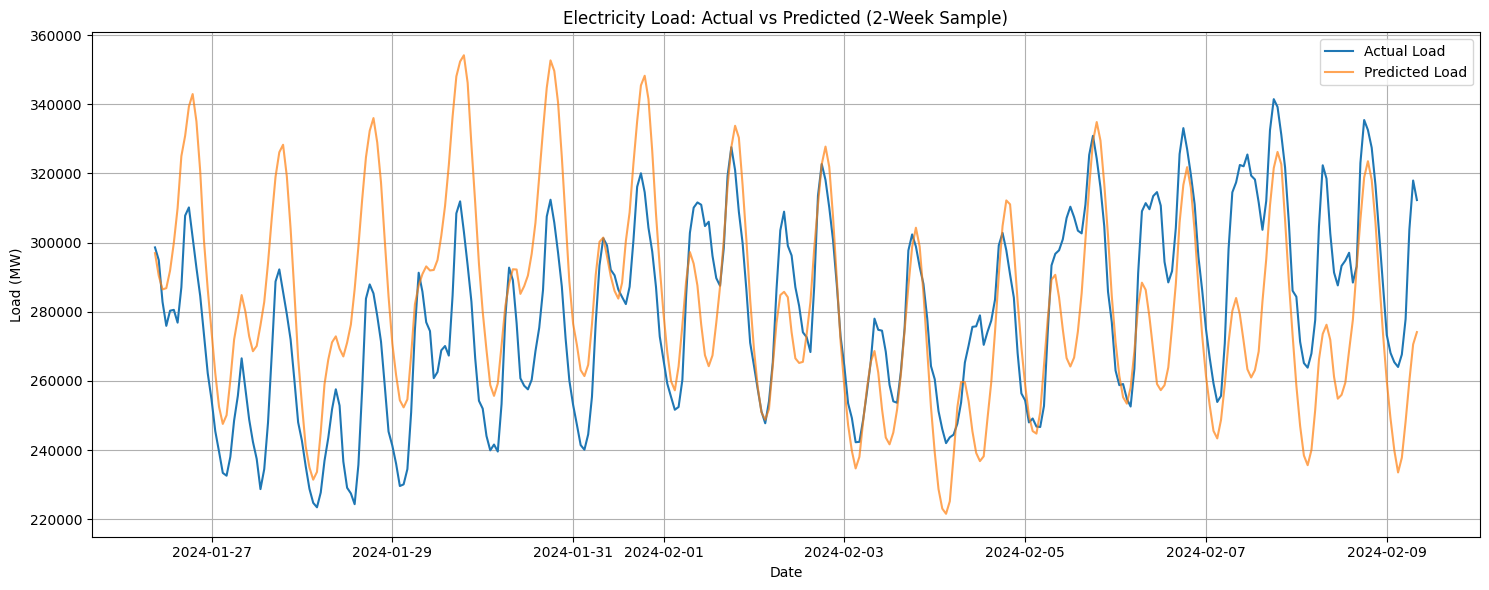

In [28]:
# Zoom in on a specific time period to see detailed predictions
if not results.empty and len(results) >= 24:
    # Select the first 2 weeks of data (or as much as available)
    sample_size = min(336, len(results))  # 14 days * 24 hours
    sample_period = results.iloc[:sample_size]
    
    plt.figure(figsize=(15, 6))
    plt.plot(sample_period['ds'], sample_period['actual'], label='Actual Load')
    plt.plot(sample_period['ds'], sample_period['predicted'], label='Predicted Load', alpha=0.7)
    plt.title('Electricity Load: Actual vs Predicted (2-Week Sample)')
    plt.xlabel('Date')
    plt.ylabel('Load (MW)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for sample period visualization.")

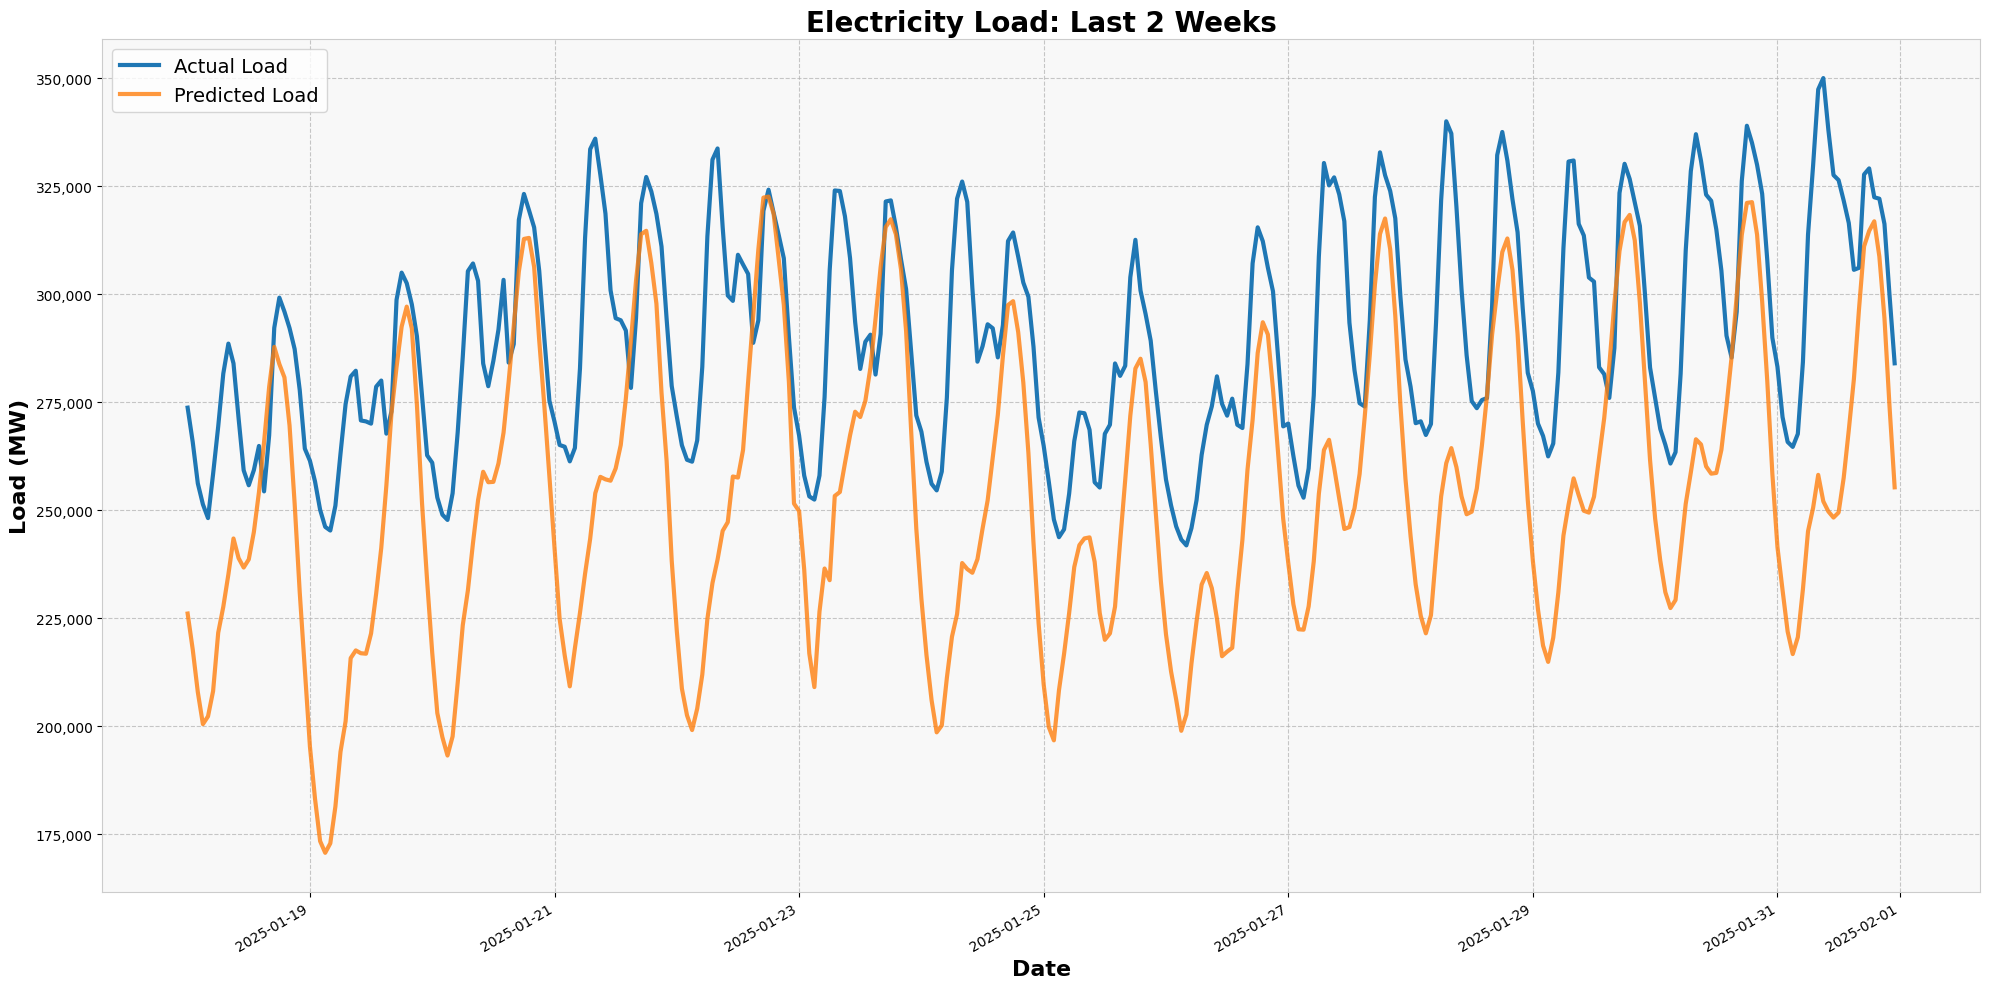

Last 2 Weeks - Mean Absolute Error (MAE): 37525.06 MW
Last 2 Weeks - Root Mean Squared Error (RMSE): 43871.72 MW
Last 2 Weeks - Mean Absolute Percentage Error (MAPE): 13.00%


In [31]:
# Get the last 2 weeks of data and compare actual vs. predicted
if not results.empty and len(results) >= 24:
    # Select the last 2 weeks of data
    hours_in_two_weeks = 14 * 24  # 14 days * 24 hours
    last_two_weeks = results.iloc[-hours_in_two_weeks:].reset_index(drop=True)
    
    # Create visualization with larger figure
    plt.figure(figsize=(20, 10))
    
    # Plot with better styling
    plt.plot(last_two_weeks['ds'], last_two_weeks['actual'], label='Actual Load', linewidth=3)
    plt.plot(last_two_weeks['ds'], last_two_weeks['predicted'], label='Predicted Load', linewidth=3, alpha=0.8)
    
    # Calculate error metrics for this period
    last_2w_mae = mean_absolute_error(last_two_weeks['actual'], last_two_weeks['predicted'])
    last_2w_rmse = np.sqrt(mean_squared_error(last_two_weeks['actual'], last_two_weeks['predicted']))
    last_2w_mape = np.mean(np.abs((last_two_weeks['actual'] - last_two_weeks['predicted']) / last_two_weeks['actual'])) * 100
    
    # Add error metrics to the plot title
    plt.title(f'Electricity Load: Last 2 Weeks', fontsize=20, fontweight='bold')
    plt.xlabel('Date', fontsize=16, fontweight='bold')
    plt.ylabel('Load (MW)', fontsize=16, fontweight='bold')
    
    # Format y-axis with comma separator for thousands
    from matplotlib.ticker import FuncFormatter
    def thousands_formatter(x, pos):
        return f"{int(x):,}"
    plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    
    # Improve legend and grid
    plt.legend(fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Improve x-axis date formatting
    plt.gcf().autofmt_xdate()
    
    # Set background and layout
    plt.gca().set_facecolor('#F8F8F8')
    for spine in plt.gca().spines.values():
        spine.set_color('#CCCCCC')
    
    plt.tight_layout()
    plt.show()
    
    # Print metrics for this period
    print(f"Last 2 Weeks - Mean Absolute Error (MAE): {last_2w_mae:.2f} MW")
    print(f"Last 2 Weeks - Root Mean Squared Error (RMSE): {last_2w_rmse:.2f} MW")
    print(f"Last 2 Weeks - Mean Absolute Percentage Error (MAPE): {last_2w_mape:.2f}%")
else:
    print("Not enough data for 2-week visualization.")

## Conclusion and Future Improvements

The Prophet model provides a reasonable prediction of electricity load based on time series data and additional features. To improve the model further, consider:

1. Incorporating additional features like day of week, holidays, and special events
2. Using more sophisticated cross-validation techniques
3. Hyperparameter tuning to optimize model performance
4. Ensemble methods combining Prophet with other models like LSTM or XGBoost